# Exercise 1: Fitting a Lorentzian Peak over a Quadratic Background

## Context
Fitting a peaked signal on top of a smooth background is one of the most common tasks in observational astrophysics and particle physics. This exercise fits a **Lorentzian (Breit-Wigner) peak** on a **quadratic polynomial background** — directly analogous to fitting X-ray emission lines (e.g. Fe Kα at 6.7 keV) over continuum thermal bremsstrahlung in galaxy cluster spectra from XMM-Newton observations.

## What I'm doing
1. Loading data into a ROOT `TH1D` histogram
2. Defining a composite fit function (Lorentzian + quadratic) as a `TF1`
3. Performing the fit using ROOT's Minuit2 minimiser
4. Plotting the result with error bars using both ROOT and `mplhep`


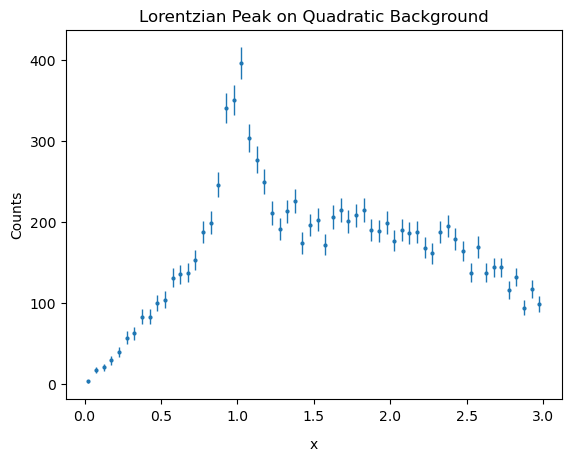

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      58.6588
NDf                       =           56
Edm                       =   3.5014e-20
NCalls                    =           90
p0                        =      -6.0062   +/-   1.49328     
p1                        =      228.485   +/-   5.18306     
p2                        =     -65.1639   +/-   1.9738      
p3                        =      77.0069   +/-   3.73726     


In [43]:
import ROOT
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
ROOT.gErrorIgnoreLevel = ROOT.kError

data = np.loadtxt("fitting-exercise-data.txt")

h = ROOT.TH1D(
    name="histo_ex1", title="Lorentzian Peak on Quadratic Background",
    nbinsx=60, xlow=0, xup=3)

h.Fill(data, np.ones(data.size))

#fit function
def fitFunction(x: np.ndarray, pars: np.ndarray) -> float:
    bg = pars[0] + pars[1]*x[0] + pars[2]*x[0]*x[0]
    num = 0.5 * pars[3] * 0.2 / np.pi
    denom = max(1.e-10, (x[0] - 1.)**2 + 0.25 * 0.04)
    peak = num / denom
    return bg + peak

#TF1 with 4 parameters
fitFcn = ROOT.TF1("fitFcn", fitFunction, xmin=0, xmax=3, npar=4)

#histogram fit
h.Fit(fitFcn)


h.GetXaxis().SetTitle("x")
h.GetXaxis().SetTitleOffset(1.5)
h.GetYaxis().SetTitle("Counts")

%jsroot on
c = ROOT.TCanvas()
h.Draw("E")
c.Draw()

#mplhep
hep.histplot(
    h,
    histtype="errorbar",
    markersize=4,
)
plt.title("Lorentzian Peak on Quadratic Background")
plt.xlabel("x", labelpad=10)
plt.ylabel("Counts")
plt.show()



# Exercise 2: RDataFrame Basics

## Context
The file `example_file.root` contains a TTree called `"dataset"` with two scalar columns: `a` and `b`. There is a normal distribution hidden in the data — to reveal it, we need to plot the natural logarithm of `a` only for entries where `b <= 0.5`.

## What I'm doing
1. Creating an RDataFrame from the ROOT file
2. Filtering rows where `b <= 0.5`
3. Defining a new column `loga` as the natural log of `a`
4. Plotting the result as a histogram, revealing the hidden Gaussian

In [50]:
import ROOT
ROOT.gErrorIgnoreLevel = ROOT.kError

#RDataFrame from ROOT file
df = ROOT.RDataFrame("dataset", "example_file.root")

h = (df.Filter("b <= 0.5")
       .Define("loga", "TMath::Log(a)")
       .Histo1D(("h", "Natural log of a (b <= 0.5)", 30, -5, 5), "loga"))

h.GetXaxis().SetTitle("ln(a)")
h.GetXaxis().SetTitleOffset(1.5)
h.GetYaxis().SetTitle("Counts")
h.SetStats(0)

%jsroot on
c = ROOT.TCanvas()
h.Draw()
c.Draw()

# Exercise 3: RDataFrame and Collections

## Context
The same dataset from Exercise 2 contains two vector columns: `vec1` and `vec2`. The elements of `vec1` are distributed as a mixture of Gaussians plus background noise. To remove the noise, we select elements of `vec1` where the square of the corresponding `vec2` element is less than 0.1.

## What I'm doing
1. Reading the same ROOT file with RDataFrame
2. Using RVec masking to filter elements within collections: `vec1[vec2*vec2 < 0.1]`
3. Plotting the filtered values to reveal the peaks of the Gaussian mixture

In [51]:
import ROOT
ROOT.gErrorIgnoreLevel = ROOT.kError

df = ROOT.RDataFrame("dataset", "example_file.root")

#vec1 elements where vec2*vec2 < 0.1
h = (df.Define("v1_to_plot", "vec1[vec2*vec2 < 0.1]")
       .Histo1D("v1_to_plot"))

h.SetStats(0)
h.GetXaxis().SetTitle("vec1")
h.GetXaxis().SetTitleOffset(1.5)
h.GetYaxis().SetTitle("Counts")
h.SetTitle("Gaussian Mixture (noise removed)")

%jsroot on
c = ROOT.TCanvas()
h.Draw()
c.Draw()